<a href="https://colab.research.google.com/github/Merenguimona/act2IA/blob/main/notebooks/Entrenamiento_y_prueba_de_modelos_basado_en_redes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src=https://upload.wikimedia.org/wikipedia/commons/4/42/UNIR_Horizontal_Logo.png style= "width: 300px; float: right; margin-right: 10px;">

# __ACTIVIDAD 2__
ASIGNATURA: Técnicas de Inteligencia Artificial
DOCENTE : Adriana Cervantes Castillo

ESTUDIANTES:

- SUSANA ALFARO LIRA
- JOSE CHABLÉ DE LA CRUZ
- JAFETH LEYVA REYNA
- WANDER PAYANO LINARES
- LUIS VEGA CABALLERO


Fecha de entrega: 13 de abril de 2026

## **Objetivos de la actividad**

Esta actividad tiene por objetivo profundizar en la aplicación de técnicas de aprendizaje supervisado, regresión y clasificación, basado en redes neuronales utilizando las librerías de `Keras` y `TensorFlow` sobre `Python`.

Para ello, como grupo de trabajo se deben de escoger dos *dataset* de plataformas online en base a requisitos mínimos y aplicando los siguientes modelos:

1. **Primer caso**: utilizar una red neuronal para realizar una regresión comparada con otra técnica no basada en redes neuronales.
2.   **Segundo caso**: utilizar una red nueronal diferente para la clasificación, de nuevo comparada con otra red de clasificación no basada en redes neuronales.



## **Pautas de elaboración**

In [1]:
import pandas as pd

In [3]:
reg_df = pd.read_csv('https://raw.githubusercontent.com/Merenguimona/act2IA/main/Datasets/weatherHistory.csv')

In [4]:
reg_df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


## Exploratory Data Analysis (EDA)

En esta sección haremos el análisis inicial para explorar los datos y tratar de predecir la variable `apparentTemperature`.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras

plt.style.use('seaborn-v0_8')

In [6]:
reg_df.shape

(96453, 12)

In [7]:
reg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [8]:
# Mostrar las primeras filas para revisar la estructura completa
display(reg_df.head())

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [9]:
# Estadísticas básicas de las variables numéricas
reg_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature (C),96453.0,11.932678,9.551546,-21.822222,4.688889,12.0000,18.838889,39.905556
Apparent Temperature (C),96453.0,10.855029,10.696847,-27.716667,2.311111,12.0000,18.838889,39.344444
Humidity,96453.0,0.734899,0.195473,0.000000,0.600000,0.7800,0.890000,1.000000
Wind Speed (km/h),96453.0,10.810640,6.913571,0.000000,5.828200,9.9659,14.135800,63.852600
Wind Bearing (degrees),96453.0,187.509232,107.383428,0.000000,116.000000,180.0000,290.000000,359.000000
Visibility (km),96453.0,10.347325,4.192123,0.000000,8.339800,10.0464,14.812000,16.100000
Loud Cover,96453.0,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Pressure (millibars),96453.0,1003.235956,116.969906,0.000000,1011.900000,1016.4500,1021.090000,1046.380000


In [11]:
# Valores faltantes y duplicados
missing = reg_df.isnull().sum().sort_values(ascending=False)
print('Valores nulos por columna:')
print(missing[missing > 0])
print('\nDuplicados:', reg_df.duplicated().sum())

Valores nulos por columna:
Precip Type    517
dtype: int64

Duplicados: 24


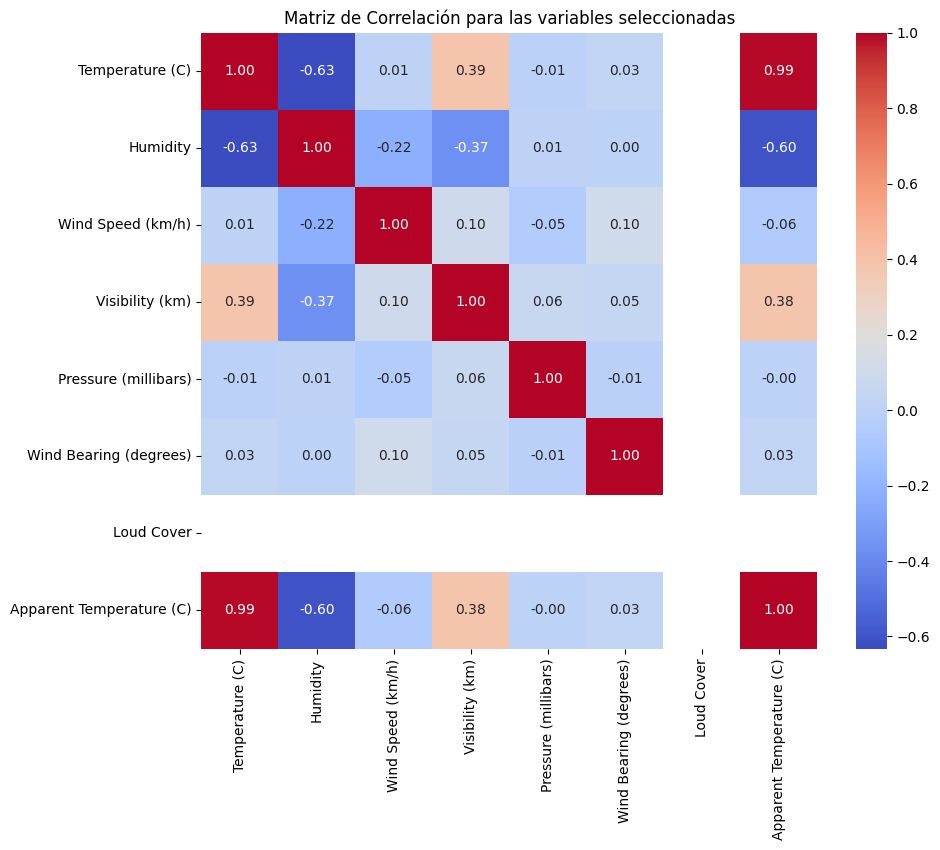

In [ ]:
# Selección de variables y análisis de correlación
selected_features = [
    'Temperature (C)',
    'Humidity',
    'Wind Speed (km/h)',
    'Visibility (km)',
    'Pressure (millibars)',
    'Wind Bearing (degrees)',
    'Loud Cover'
]
target = 'Apparent Temperature (C)'

corr_columns = selected_features + [target]
corr_matrix = reg_df[corr_columns].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_columns)), corr_columns, rotation=45, ha='right')
plt.yticks(range(len(corr_columns)), corr_columns)
for i in range(len(corr_columns)):
    for j in range(len(corr_columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')
plt.title('Matriz de Correlación para las variables seleccionadas')
plt.tight_layout()
plt.show()

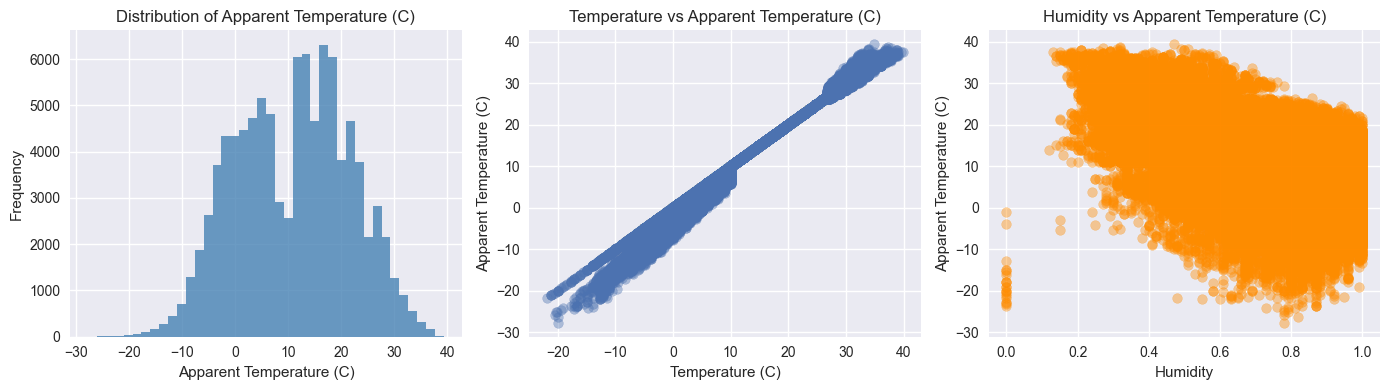

In [17]:
# Distribución del target y comparación con algunas variables clave
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.hist(reg_df[target].dropna(), bins=40, color='steelblue', alpha=0.8)
plt.title('Distribution of Apparent Temperature (C)')
plt.xlabel(target)
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.scatter(reg_df['Temperature (C)'], reg_df[target], alpha=0.4)
plt.title('Temperature vs Apparent Temperature (C)')
plt.xlabel('Temperature (C)')
plt.ylabel(target)

plt.subplot(1, 3, 3)
plt.scatter(reg_df['Humidity'], reg_df[target], alpha=0.4, color='darkorange')
plt.title('Humidity vs Apparent Temperature (C)')
plt.xlabel('Humidity')
plt.ylabel(target)

plt.tight_layout()
plt.show()

## Regression pipeline con red neuronal

Construimos una tubería que normaliza los datos, entrena una red neuronal para predecir `apparentTemperature`, y evalúa el rendimiento sobre un conjunto de prueba.

In [18]:
# Preparación de datos para el modelo
model_df = reg_df[selected_features + [target]].dropna()
X = model_df[selected_features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)

Training set: (77162, 7)
Test set: (19291, 7)


In [20]:
%pip install scikeras

from scikeras.wrappers import KerasRegressor

# Definición del modelo Keras
def build_regressor():
    model = keras.Sequential([
        keras.layers.Input(shape=(len(selected_features),)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Crear y entrenar el pipeline de regresión
reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nn', KerasRegressor(
        model=build_regressor,
        epochs=50,
        batch_size=64,
        verbose=0
    ))
])

reg_pipeline.fit(X_train, y_train)

     ---------------------------------------- 8.1/8.1 MB 896.8 kB/s eta 0:00:00
     -------------------------------------- 12.6/12.6 MB 889.4 kB/s eta 0:00:00
     -------------------------------------- 36.6/36.6 MB 866.0 kB/s eta 0:00:00
     ------------------------------------ 309.1/309.1 kB 911.1 kB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.1.0
    Uninstalling threadpoolctl-3.1.0:
      Successfully uninstalled threadpoolctl-3.1.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\elvla\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\~umpy\\.libs\\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ModuleNotFoundError: No module named 'scikeras'

In [ ]:
# Evaluación de rendimiento
y_pred = reg_pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R²: {r2:.3f}')

In [ ]:
# Comparar algunas predicciones reales vs. estimadas
comparison = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred
}).reset_index(drop=True)
comparison.head(10)
